In [71]:
import warnings 
warnings.filterwarnings('ignore')

In [148]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import zscore
from sklearn import model_selection
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score
from sklearn.metrics import roc_curve, auc
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
# To enable plotting graphs in Jupyter notebook
%matplotlib inline 

In [74]:
park_data = pd.read_csv("Parkinsons.data")

In [75]:
park_data.shape

(195, 24)

In [76]:
park_data.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [77]:
park_data.head(24)

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
5,phon_R01_S01_6,120.552,131.162,113.787,0.00968,0.00008,0.00463,0.00750,0.01388,0.04701,...,0.06985,0.01222,21.378,1,0.415564,0.825069,-4.242867,0.299111,2.187560,0.357775
6,phon_R01_S02_1,120.267,137.244,114.820,0.00333,0.00003,0.00155,0.00202,0.00466,0.01608,...,0.02337,0.00607,24.886,1,0.596040,0.764112,-5.634322,0.257682,1.854785,0.211756
7,phon_R01_S02_2,107.332,113.840,104.315,0.00290,0.00003,0.00144,0.00182,0.00431,0.01567,...,0.02487,0.00344,26.892,1,0.637420,0.763262,-6.167603,0.183721,2.064693,0.163755
8,phon_R01_S02_3,95.730,132.068,91.754,0.00551,0.00006,0.00293,0.00332,0.00880,0.02093,...,0.03218,0.01070,21.812,1,0.615551,0.773587,-5.498678,0.327769,2.322511,0.231571
9,phon_R01_S02_4,95.056,120.103,91.226,0.00532,0.00006,0.00268,0.00332,0.00803,0.02838,...,0.04324,0.01022,21.862,1,0.547037,0.798463,-5.011879,0.325996,2.432792,0.271362


In [78]:
park_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [79]:
park_data.describe().T

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [80]:
park_data.apply(lambda x : sum(x.isnull()))

name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

In [81]:
#Name of the patient doesnt have anything to do with de
park_data = park_data.drop('name',axis=1)

In [82]:
#Let's check the correlation 
park_data.corr()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
MDVP:Fo(Hz),1.000000,0.400985,0.596546,-0.118003,-0.382027,-0.076194,-0.112165,-0.076213,-0.098374,-0.073742,...,-0.094732,-0.021981,0.059144,-0.383535,-0.383894,-0.446013,-0.413738,-0.249450,0.177980,-0.372356
MDVP:Fhi(Hz),0.400985,1.000000,0.084951,0.102086,-0.029198,0.097177,0.091126,0.097150,0.002281,0.043465,...,-0.003733,0.163766,-0.024893,-0.166136,-0.112404,-0.343097,-0.076658,-0.002954,0.176323,-0.069543
MDVP:Flo(Hz),0.596546,0.084951,1.000000,-0.139919,-0.277815,-0.100519,-0.095828,-0.100488,-0.144543,-0.119089,...,-0.150737,-0.108670,0.210851,-0.380200,-0.400143,-0.050406,-0.394857,-0.243829,-0.100629,-0.340071
MDVP:Jitter(%),-0.118003,0.102086,-0.139919,1.000000,0.935714,0.990276,0.974256,0.990276,0.769063,0.804289,...,0.746635,0.906959,-0.728165,0.278220,0.360673,0.098572,0.693577,0.385123,0.433434,0.721543
MDVP:Jitter(Abs),-0.382027,-0.029198,-0.277815,0.935714,1.000000,0.922911,0.897778,0.922913,0.703322,0.716601,...,0.697170,0.834972,-0.656810,0.338653,0.441839,0.175036,0.735779,0.388543,0.310694,0.748162
MDVP:RAP,-0.076194,0.097177,-0.100519,0.990276,0.922911,1.000000,0.957317,1.000000,0.759581,0.790652,...,0.744919,0.919521,-0.721543,0.266668,0.342140,0.064083,0.648328,0.324407,0.426605,0.670999
MDVP:PPQ,-0.112165,0.091126,-0.095828,0.974256,0.897778,0.957317,1.000000,0.957319,0.797826,0.839239,...,0.763592,0.844604,-0.731510,0.288698,0.333274,0.196301,0.716489,0.407605,0.412524,0.769647
Jitter:DDP,-0.076213,0.097150,-0.100488,0.990276,0.922913,1.000000,0.957319,1.000000,0.759555,0.790621,...,0.744901,0.919548,-0.721494,0.266646,0.342079,0.064026,0.648328,0.324377,0.426556,0.671005
MDVP:Shimmer,-0.098374,0.002281,-0.144543,0.769063,0.703322,0.759581,0.797826,0.759555,1.000000,0.987258,...,0.987626,0.722194,-0.835271,0.367430,0.447424,0.159954,0.654734,0.452025,0.507088,0.693771
MDVP:Shimmer(dB),-0.073742,0.043465,-0.119089,0.804289,0.716601,0.790652,0.839239,0.790621,0.987258,1.000000,...,0.963202,0.744477,-0.827805,0.350697,0.410684,0.165157,0.652547,0.454314,0.512233,0.695058


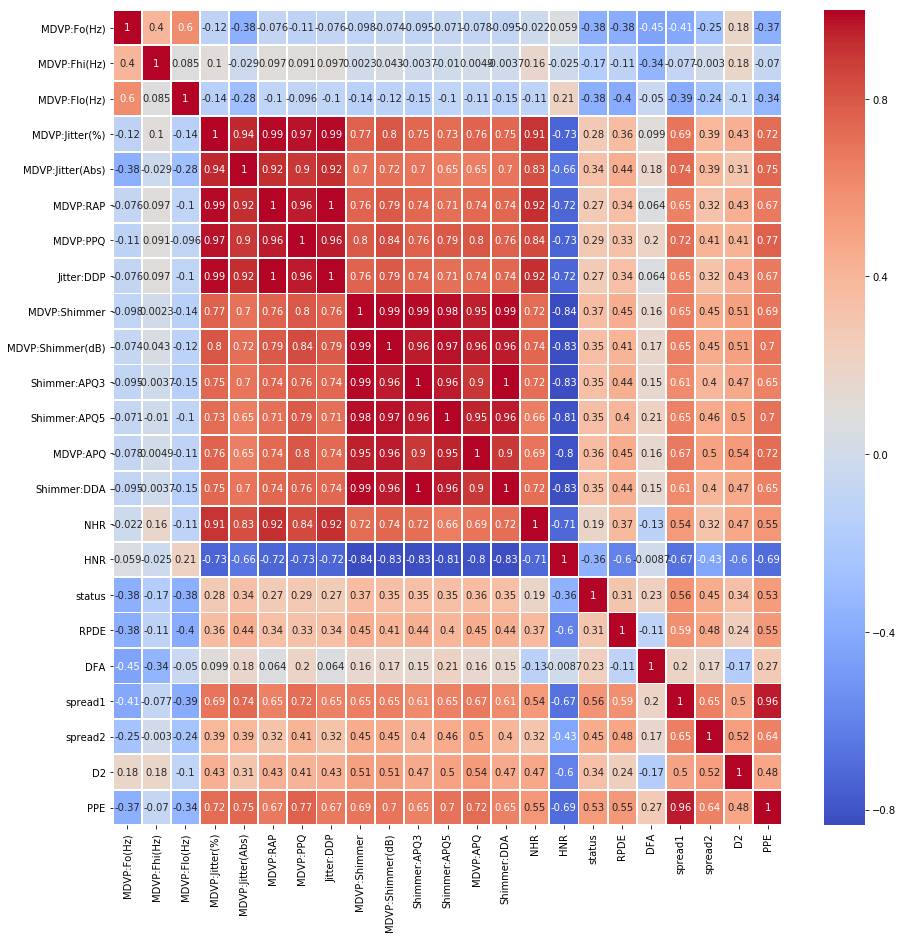

In [83]:
#And plot the heat map for correlation too
fig, ax = plt.subplots(figsize=(15,15))
sns.heatmap(park_data.corr(), annot=True, linewidths=0.8, ax=ax,cmap='coolwarm')

In [84]:
#MDVP:Jitter(%) is highly corelated with MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP  so we can drop MDVP:Jitter(%)
#MDVP:Shimmer is highly corelated withMDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA  
#Spread1 is highly corelated with PPE. we can drop spread1   
park_data = park_data.drop(['MDVP:Jitter(%)','MDVP:Shimmer','spread1'],axis=1)

In [85]:
park_data.columns

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(Abs)',
       'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer(dB)',
       'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR',
       'status', 'RPDE', 'DFA', 'spread2', 'D2', 'PPE'],
      dtype='object')

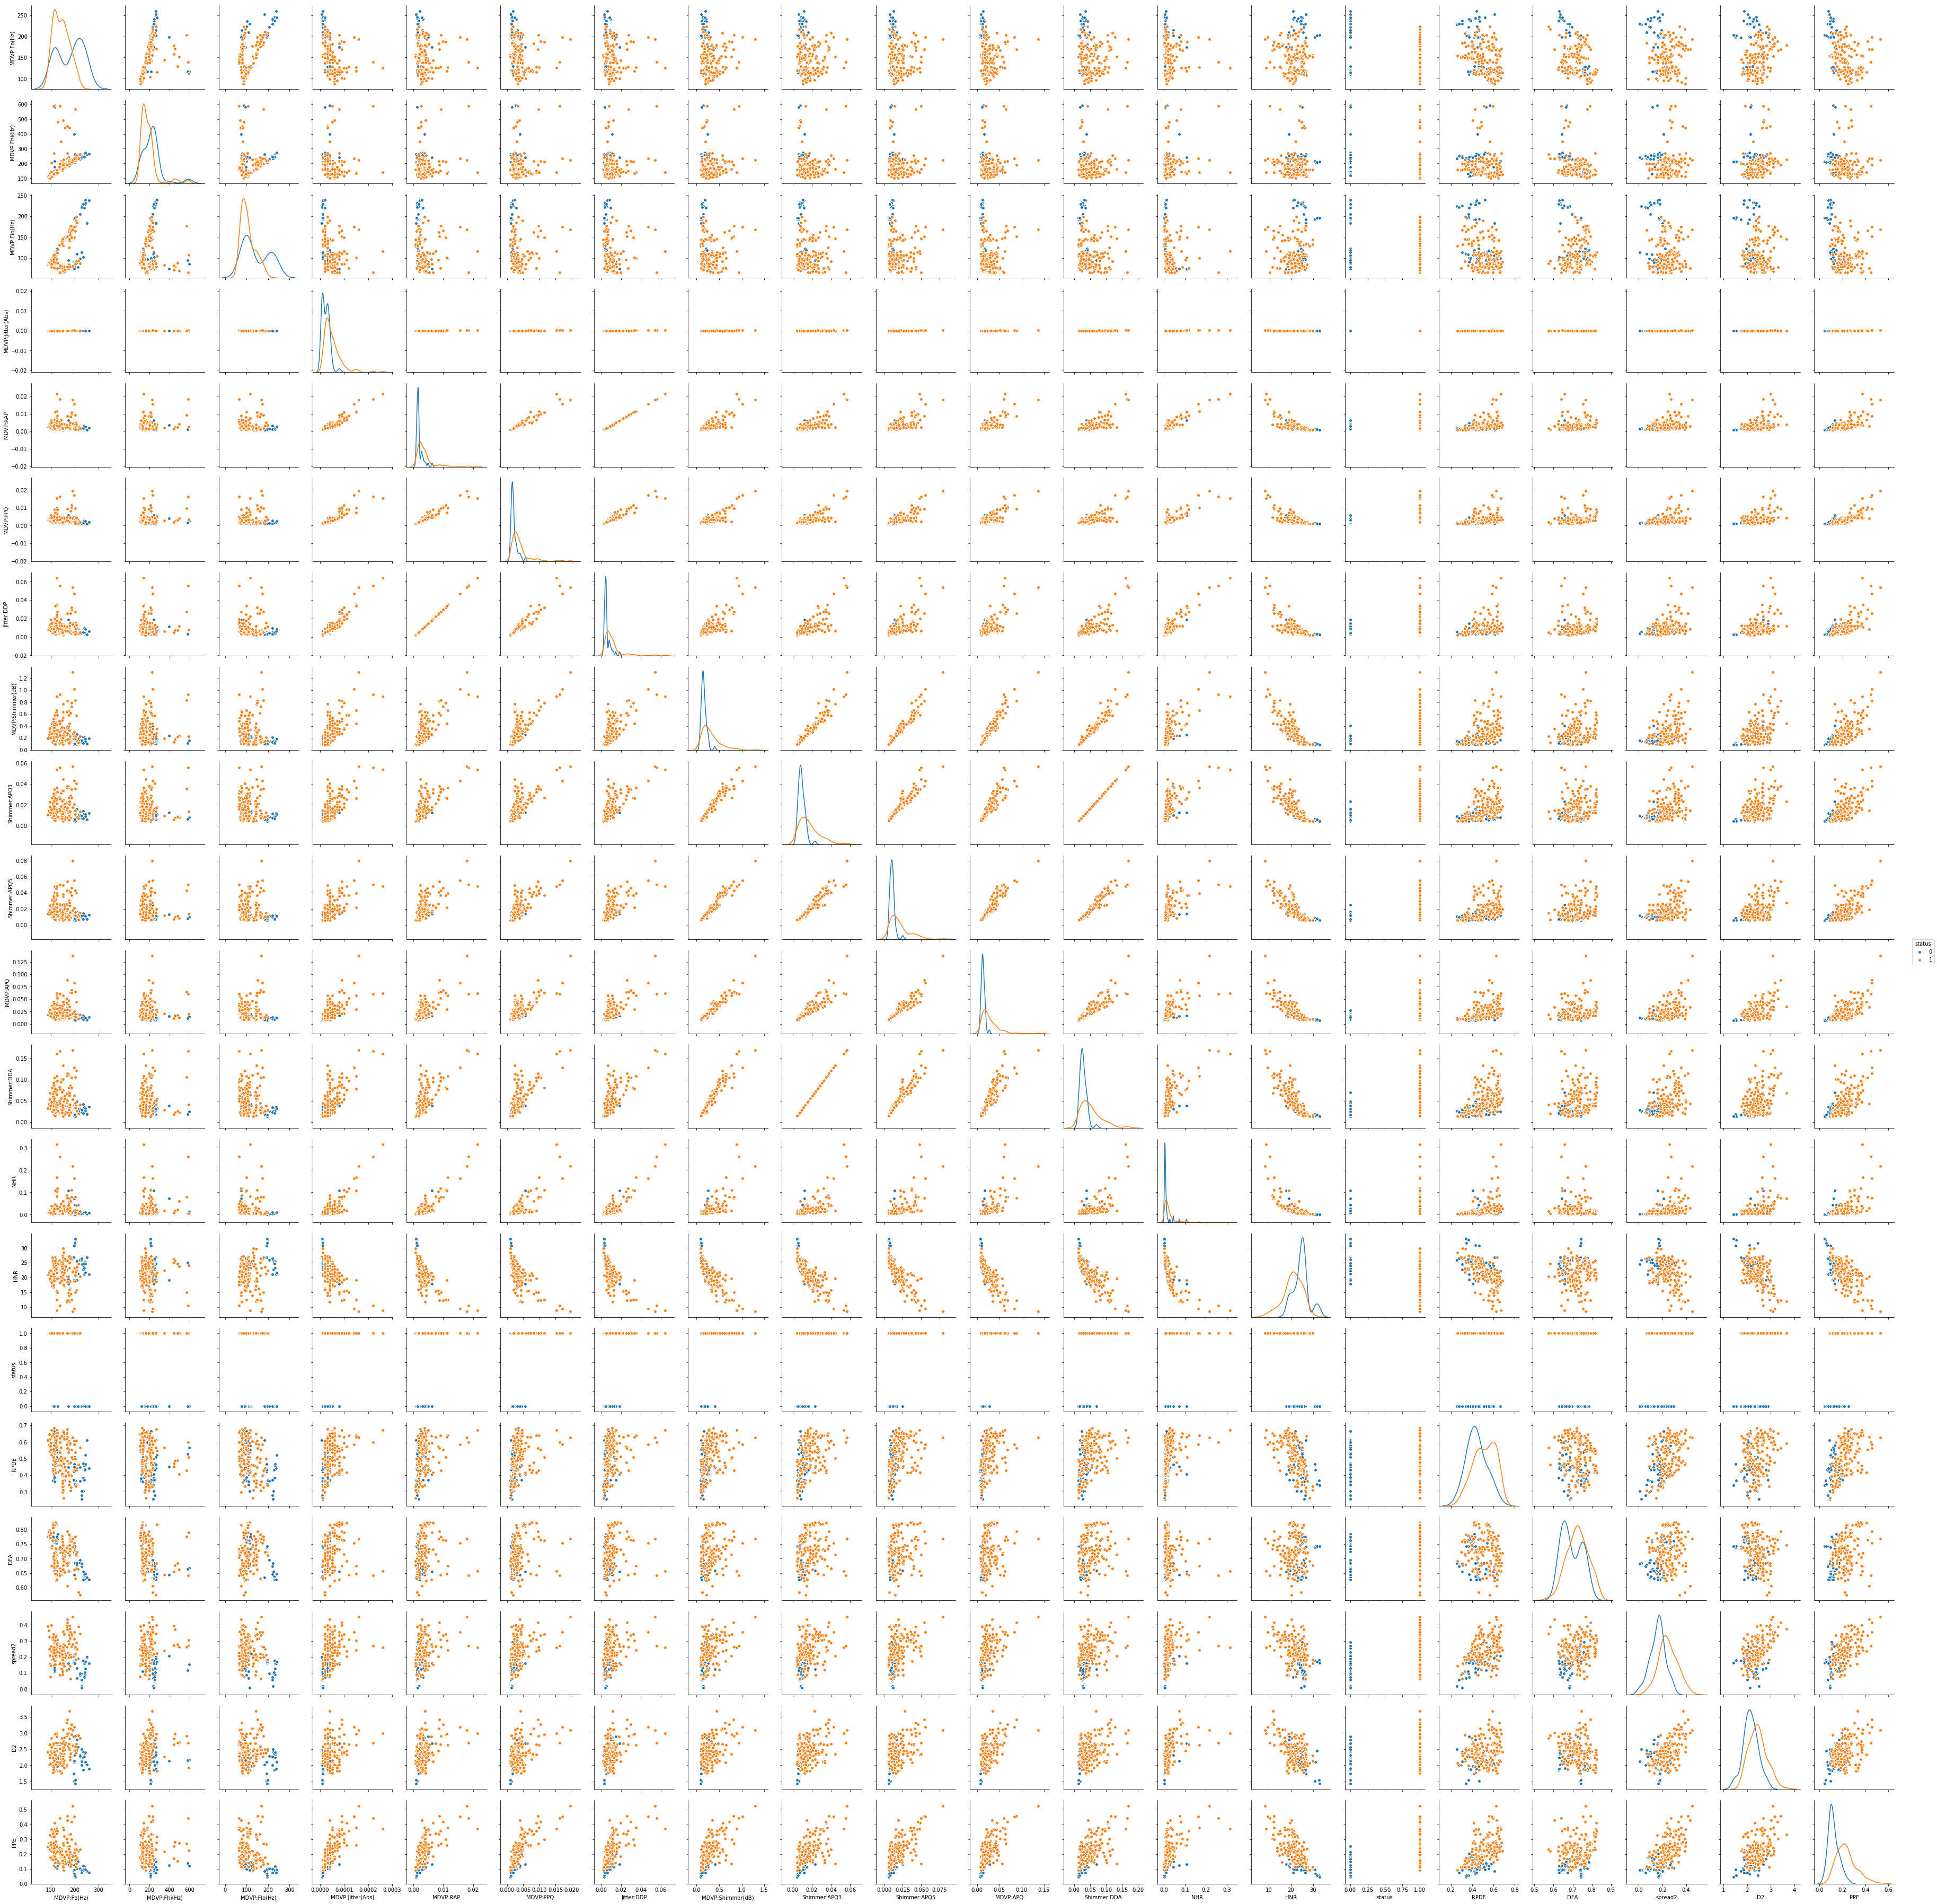

In [86]:
sns.pairplot(park_data,hue='status',diag_kind='kde')

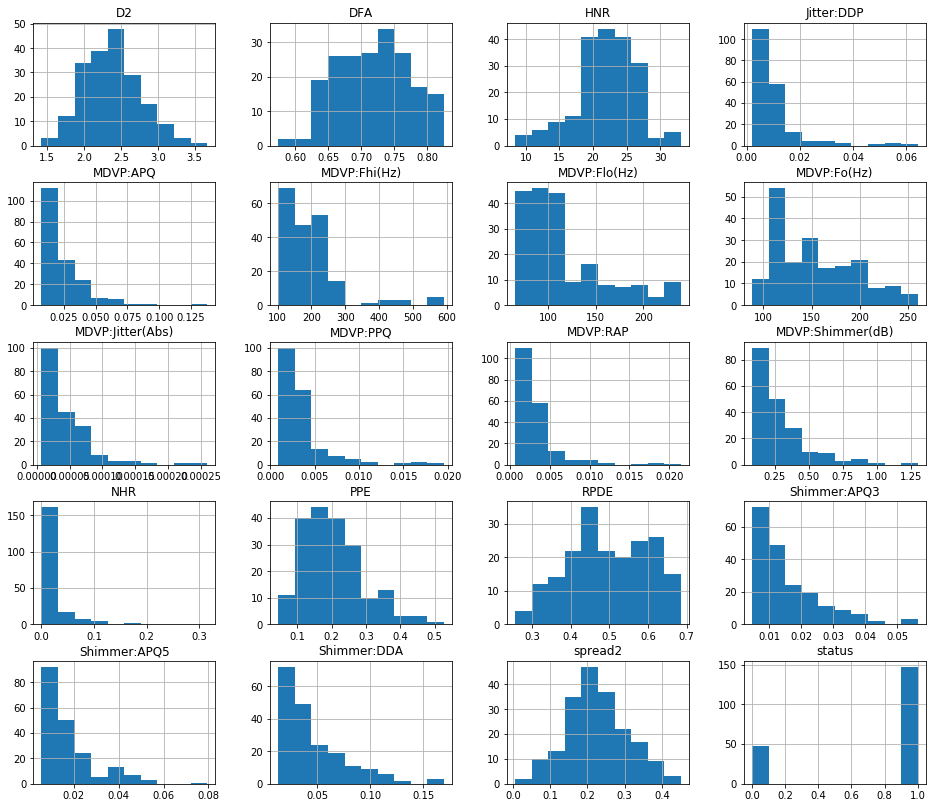

In [87]:
hist = park_data.hist(bins=10, figsize=(16, 14))


In [88]:
y=park_data[['status']]
X=park_data.drop(['status'],axis=1)

In [89]:
test_size = 0.3 # taking 70:30 training and test set
seed = 4  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)


In [90]:
#Simple Decision Tree model without any parameter tuning
model=DecisionTreeClassifier(criterion='entro1`py',random_state=2)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=2,
            splitter='best')

In [91]:
y_predict=model.predict(X_test)
metrics.accuracy_score(y_test,y_predict)

0.8813559322033898

In [92]:
metrics.confusion_matrix(y_test,y_predict)

array([[11,  5],
       [ 2, 41]], dtype=int64)

In [93]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.8813559322033898
Test Recall    = 0.9534883720930233
Test Precision = 0.8913043478260869
Test F1score   = 0.9213483146067417


### This function will create dataframe with different max depth values. This will help us in finding optimal depth

In [94]:
def get_max_depth(max_depth_list,X_train,y_train,X_test):
    df_max_depth = pd.DataFrame(columns=['max_depth', 'accuracy','AUC'])
    for x in max_depth_list:
        model=DecisionTreeClassifier(criterion='entropy',max_depth = x,random_state=2)
        model.fit(X_train,y_train)
        y_predict=model.predict(X_test)
        acc_scr = metrics.accuracy_score(y_test,y_predict)
        fpr, tpr, thresholds = roc_curve(y_test, y_predict)
        roc_auc = auc(fpr, tpr)
        df_max_depth = df_max_depth.append({'max_depth':x,'accuracy':acc_scr,'AUC':roc_auc},ignore_index=True)
    line1, = plt.plot(df_max_depth['max_depth'], df_max_depth['accuracy'],'b', label="accuracy")
    line2, = plt.plot(df_max_depth['max_depth'], df_max_depth['AUC'], 'r', label="AUC")
    plt.ylabel('accuracy-AUC')
    plt.xlabel('n_estimators')
    plt.show()    
    return (df_max_depth)

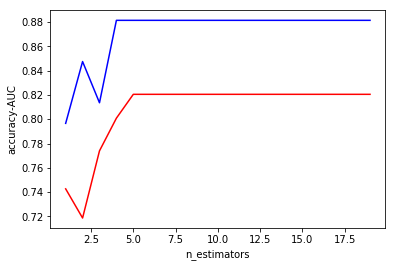

In [95]:
max_depth_list = []
for i in range(1,20):
    max_depth_list.append(i)
df_h = pd.DataFrame(get_max_depth(max_depth_list,X_train,y_train,X_test))


In [96]:
df_h

,max_depth,accuracy,AUC
0,1.0,0.796610,0.742733
1,2.0,0.847458,0.718750
2,3.0,0.813559,0.773983
3,4.0,0.881356,0.800872
4,5.0,0.881356,0.820494
5,6.0,0.881356,0.820494
6,7.0,0.881356,0.820494
7,8.0,0.881356,0.820494
8,9.0,0.881356,0.820494
9,10.0,0.881356,0.820494


### From the above data - at Max depth 5 we are getting good accuracy and auc score.
### Below fundction will check for accuracy and auc for different leaf values with max depth = 5

In [97]:
def get_min_leaf(min_leaf_list,X_train,y_train,X_test):
    df_min_sample_leaf = pd.DataFrame(columns=['min_sample_leaf', 'accuracy','AUC'])
    for x in min_leaf_list:
        model=DecisionTreeClassifier(criterion='entropy',max_depth = 5,min_samples_leaf = x,random_state=2)
        model.fit(X_train,y_train)
        y_predict=model.predict(X_test)
        acc_scr = metrics.accuracy_score(y_test,y_predict)
        fpr, tpr, thresholds = roc_curve(y_test, y_predict)
        roc_auc = auc(fpr, tpr)
        df_min_sample_leaf = df_min_sample_leaf.append({'min_sample_leaf':x,'accuracy':acc_scr,'AUC':roc_auc},ignore_index=True)
    line1, = plt.plot(df_min_sample_leaf['min_sample_leaf'], df_min_sample_leaf['accuracy'],'b', label="accuracy")
    line2, = plt.plot(df_min_sample_leaf['min_sample_leaf'], df_min_sample_leaf['AUC'], 'r', label="AUC")
    plt.ylabel('accuracy-AUC')
    plt.xlabel('min_sample_leaf')
    plt.show()
        
    return (df_min_sample_leaf)
    

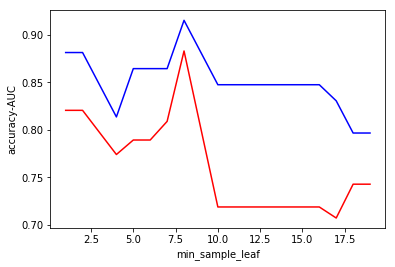

In [98]:
min_leaf_list = []
for i in range(1,20):
    min_leaf_list.append(i)
df_m = pd.DataFrame(get_min_leaf(min_leaf_list,X_train,y_train,X_test))

In [99]:
df_m

,min_sample_leaf,accuracy,AUC
0,1.0,0.881356,0.820494
1,2.0,0.881356,0.820494
2,3.0,0.847458,0.797238
3,4.0,0.813559,0.773983
4,5.0,0.864407,0.789244
5,6.0,0.864407,0.789244
6,7.0,0.864407,0.808866
7,8.0,0.915254,0.882994
8,9.0,0.881356,0.800872
9,10.0,0.847458,0.718750


### From the above data - optimal value of min leaf sample is arround 8

### Build the decision tree model with max depth = 5 and min leaf sample = 8

In [100]:
model=DecisionTreeClassifier(criterion='entropy',max_depth = 5,min_samples_leaf = 8, random_state=2)
model.fit(X_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=8, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=2,
            splitter='best')

In [101]:
y_predict=model.predict(X_test)
metrics.accuracy_score(y_test,y_predict)

0.9152542372881356

In [102]:
metrics.confusion_matrix(y_test,y_predict)

array([[13,  3],
       [ 2, 41]], dtype=int64)

In [103]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.9152542372881356
Test Recall    = 0.9534883720930233
Test Precision = 0.9318181818181818
Test F1score   = 0.942528735632184


### As the values in the data set are numerical and there is no optimal range is provided for features, lets try to normalize the data and check the score

In [104]:
X_z = X.apply(zscore)
test_size = 0.3 # taking 70:30 training and test set
seed = 4  # Random numbmer seeding for reapeatability of the code
X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(X_z, y, test_size=test_size, random_state=seed)

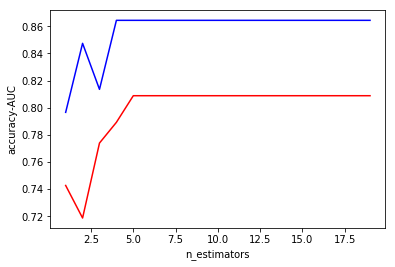

In [105]:
max_depth_list = []
for i in range(1,20):
    max_depth_list.append(i)
df_h = get_max_depth(max_depth_list,X_train_z,y_train_z, X_test_z)

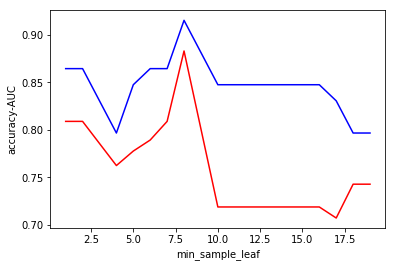

In [106]:
min_leaf_list = []
for i in range(1,20):
    min_leaf_list.append(i)
df_m = get_min_leaf(min_leaf_list,X_train_z,y_train_z, X_test_z)

### After applying Z score to features and checking for optimal max depth and min leaf, max depth is still 5 and min leaf is 8.
### Lets build the model and check scores

In [107]:
model=DecisionTreeClassifier(criterion='entropy',max_depth = 5,min_samples_leaf = 8, random_state=2)
model.fit(X_train_z,y_train_z)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=8, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=2,
            splitter='best')

In [108]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.9152542372881356
Test Recall    = 0.9534883720930233
Test Precision = 0.9318181818181818
Test F1score   = 0.942528735632184


### There is not much improvement after applying Z score. 
### Trying standard scallar

In [109]:
from sklearn.preprocessing import StandardScaler
scaler_x = StandardScaler()
rescaledX_train = scaler_x.fit_transform(X_train)
rescaledX_test = scaler_x.transform(X_test)

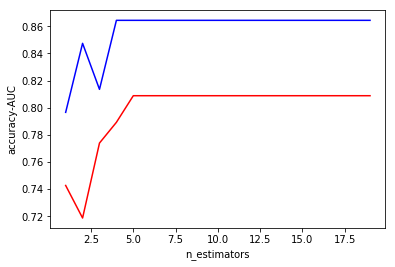

In [110]:
max_depth_list = []
for i in range(1,20):
    max_depth_list.append(i)
df_h = get_max_depth(max_depth_list,rescaledX_train,y_train,rescaledX_test)

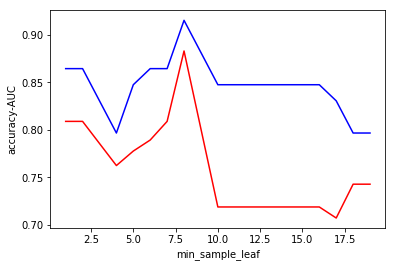

In [111]:
min_leaf_list = []
for i in range(1,20):
    min_leaf_list.append(i)
df_h = get_min_leaf(min_leaf_list,rescaledX_train,y_train,rescaledX_test)

In [112]:
###Max depth and sample leaf remain same

In [113]:
model_dt=DecisionTreeClassifier(criterion='entropy',max_depth = 5,min_samples_leaf = 8, random_state=2)
model_dt.fit(rescaledX_train,y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=5,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=8, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=2,
            splitter='best')

In [114]:
y_predict=model_dt.predict(rescaledX_test)

In [115]:
metrics.confusion_matrix(y_test,y_predict)

array([[13,  3],
       [ 2, 41]], dtype=int64)

In [116]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.9152542372881356
Test Recall    = 0.9534883720930233
Test Precision = 0.9318181818181818
Test F1score   = 0.942528735632184


### scores have been improved after using standard scallar

### Random Forest

In [117]:
from sklearn.ensemble import RandomForestClassifier

In [118]:
y=park_data[['status']]
X=park_data.drop(['status'],axis=1)
test_size = 0.3 # taking 70:30 training and test set
seed = 4  # Random numbmer seeding for reapeatability of the code
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

### Simple model without any parameter tuning

In [119]:
rf = RandomForestClassifier(criterion = 'entropy',random_state = 2)
rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=10, n_jobs=1,
            oob_score=False, random_state=2, verbose=0, warm_start=False)

In [120]:
y_predict = rf.predict(X_test)

In [121]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.864406779661017
Test Recall    = 0.9534883720930233
Test Precision = 0.8723404255319149
Test F1score   = 0.9111111111111112


### lets find the optimal value for n_estimators

In [122]:
def get_n_estimator(n_est_list,X_train,y_train,X_test):
      
    df_n_est = pd.DataFrame(columns=['n_est', 'accuracy','AUC'])
    for x in n_est_list:
        model=RandomForestClassifier(n_estimators = x,criterion='entropy',random_state=2)
        model.fit(X_train,y_train)
        y_predict=model.predict(X_test)
        acc_scr = metrics.accuracy_score(y_test,y_predict)
        fpr, tpr, thresholds = roc_curve(y_test, y_predict)
        roc_auc = auc(fpr, tpr)
        df_n_est = df_n_est.append({'n_est':x,'accuracy':acc_scr,'AUC':roc_auc},ignore_index=True)
        
    line1, = plt.plot(df_n_est['n_est'], df_n_est['accuracy'],'b', label="accuracy")
    line2, = plt.plot(df_n_est['n_est'], df_n_est['AUC'], 'r', label="AUC")
    plt.ylabel('accuracy-AUC')
    plt.xlabel('n_estimators')
    plt.show()    
        
    return (df_n_est)

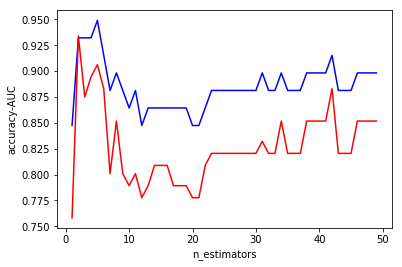

In [123]:
n_est_list = []
for i in range(1,50):
    n_est_list.append(i)
df_rd = get_n_estimator(n_est_list,X_train,y_train,X_test)

In [124]:
df_rd

,n_est,accuracy,AUC
0,1.0,0.847458,0.757994
1,2.0,0.932203,0.933866
2,3.0,0.932203,0.875000
3,4.0,0.932203,0.894622
4,5.0,0.949153,0.906250
5,6.0,0.915254,0.882994
6,7.0,0.881356,0.800872
7,8.0,0.898305,0.851744
8,9.0,0.881356,0.800872
9,10.0,0.864407,0.789244


### optimal value of n_estimators = 5
### Lets find the min leaf when n_estimators = 5

In [137]:
def get_min_leaf_rf(min_leaf_list,X_train,y_train,X_test):
    df_min_leaf_rf = pd.DataFrame(columns=['min_leaf', 'accuracy','AUC'])
    for x in min_leaf_list:
        model=RandomForestClassifier(n_estimators = 5,min_samples_leaf = x,criterion='entropy',random_state=2)
        model.fit(X_train,y_train)
        y_predict=model.predict(X_test)
        acc_scr = metrics.accuracy_score(y_test,y_predict)
        fpr, tpr, thresholds = roc_curve(y_test, y_predict)
        roc_auc = auc(fpr, tpr)
        df_min_leaf_rf = df_min_leaf_rf.append({'min_leaf':x,'accuracy':acc_scr,'AUC':roc_auc},ignore_index=True)
        
    line1, = plt.plot(df_min_leaf_rf['min_leaf'], df_min_leaf_rf['accuracy'],'b', label="accuracy")
    line2, = plt.plot(df_min_leaf_rf['min_leaf'], df_min_leaf_rf['AUC'], 'r', label="AUC")
    plt.ylabel('accuracy-AUC')
    plt.xlabel('min_leaf')
    plt.show()    
    
    return (df_min_leaf_rf)
    

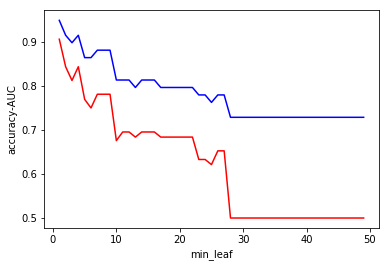

In [138]:
min_leaf_list = []
for i in range(1,50):
    min_leaf_list.append(i)
df_rd = get_min_leaf_rf(n_est_list,X_train,y_train,X_test)

In [129]:
df_rd

,min_leaf,accuracy,AUC
0,1.0,0.949153,0.906250
1,2.0,0.915254,0.843750
2,3.0,0.898305,0.812500
3,4.0,0.915254,0.843750
4,5.0,0.864407,0.769622
5,6.0,0.864407,0.750000
6,7.0,0.881356,0.781250
7,8.0,0.881356,0.781250
8,9.0,0.881356,0.781250
9,10.0,0.813559,0.675872


### optimal n_estimators = 5 and min leaf = 1

In [139]:
rf = RandomForestClassifier(n_estimators= 5,min_samples_leaf=1,criterion = 'entropy',random_state = 2)
rf.fit(X_train, y_train)
y_predict = rf.predict(X_test)

In [140]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.9491525423728814
Test Recall    = 1.0
Test Precision = 0.9347826086956522
Test F1score   = 0.9662921348314606


### Trying Standard scaller to check if there is any improvement after scaling

In [141]:
from sklearn.preprocessing import StandardScaler
scale_x = StandardScaler()
rescaledX_train = scale_x.fit_transform(X_train)
rescaledX_test = scale_x.transform(X_test)

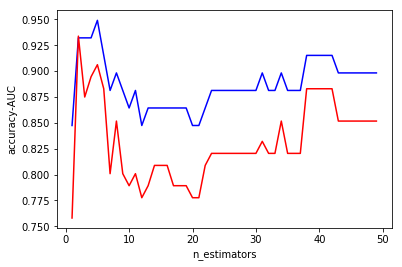

In [142]:
n_est_list = []
for i in range(1,50):
    n_est_list.append(i)
df_rd = get_n_estimator(n_est_list,rescaledX_train,y_train,rescaledX_test)

In [134]:
df_rd

,n_est,accuracy,AUC
0,1.0,0.847458,0.757994
1,2.0,0.932203,0.933866
2,3.0,0.932203,0.875000
3,4.0,0.932203,0.894622
4,5.0,0.949153,0.906250
5,6.0,0.915254,0.882994
6,7.0,0.881356,0.800872
7,8.0,0.898305,0.851744
8,9.0,0.881356,0.800872
9,10.0,0.864407,0.789244


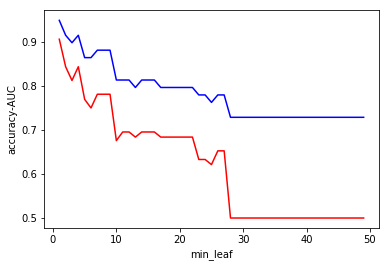

In [143]:
min_leaf_list = []
for i in range(1,50):
    min_leaf_list.append(i)
df_rd = get_min_leaf_rf(min_leaf_list,rescaledX_train,y_train,rescaledX_test)

In [144]:
rf = RandomForestClassifier(n_estimators= 5,min_samples_leaf=1,criterion = 'entropy',random_state = 2)
rf.fit(rescaledX_train, y_train)
y_predict = rf.predict(rescaledX_test)

In [145]:
print ("Test Accuracy  =", metrics.accuracy_score(y_test,y_predict))
print ("Test Recall    =", metrics.recall_score(y_test,y_predict))
print ("Test Precision =", metrics.precision_score(y_test,y_predict))
print ("Test F1score   =", metrics.f1_score(y_test,y_predict))

Test Accuracy  = 0.9491525423728814
Test Recall    = 1.0
Test Precision = 0.9347826086956522
Test F1score   = 0.9662921348314606


### there is not much improvement after scaling

In [ ]:
### From the above analysis we can conclude that Random Forest should be used for this dataset.

In [ ]:
### Trying k fold cross validation

In [146]:
models = []
models.append(('DecisionTree', model_dt))
models.append(('RandomForest', rf))

DecisionTree: 0.888378 (0.005735)
RandomForest: 0.908159 (0.006676)


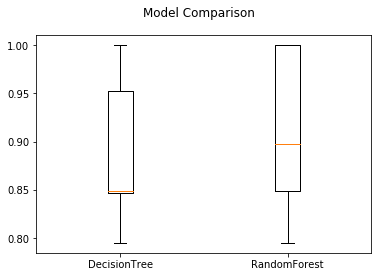

In [151]:
# evaluate each model in turn after doing 5 fold comparisions
results = []
names = []
for name, model in models:
    kfold = model_selection.KFold(n_splits=5,random_state=2)
    cv_results = model_selection.cross_val_score(model, X, y, cv=kfold, scoring='recall')
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, np.mean(cv_results), cv_results.var())
    print(msg)
# boxplot algorithm comparison
fig = plt.figure()
fig.suptitle('Model Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
### We can use Random Forest to get better result